过拟合总是可以通过是收集更多的训练数据来缓解
但当已经收集到尽可能多的数据时，应当转而关注正则化技术

**通过函数与“零”的距离来度量函数的复杂度**

对于线性回归 $f(x) = w^T x$，可以采用权重 w 的模来衡量函数的复杂度（只惩罚权重，不惩罚偏置）

主要这里的特征 x 和原始特征 $x_1,x_2,\dots$ 不同，x 可能还包含 $x_1x_2,x_1^2$ 等人工构造高阶特征

可以将所有多项式组合全扔进模型里，通过正则化调整参数，对于不重要的特征模型回将其权重压缩到很小，最后再剔除该特征即可
problems：
- 特征维度爆炸，计算量很大
- 大量高度相关多项式特征会造成多重共线性，模型不稳定
solutions：
1. 人工前置控制
   提前限制多项式范围，如限定最高阶，业务逻辑过滤交叉项等
2. 过滤式筛选
   - 方差筛选：删除方差接近 0 的特征
   - 单变量相关性筛选：计算每个特征与标签 y 的相关系数，设置阈值，删掉相关性极低的特征
   - 对于高度相关的多个特征，只保留一个
   

In [1]:
import torch
from torch import nn
from d2l import torch as d2l

n_train, n_test, num_inputs, batch_size = 100, 100, 200, 5
true_w = torch.ones((num_inputs, 1)) * 0.01
true_b = 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

In [3]:
def train_concise(wd): # wd为权重衰减系数
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    trainer = torch.optim.SGD([{"params":net[0].weight, 'weight_decay': wd},{"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log', xlim=[5, num_epochs], legend=['train', 'test'])

    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()        # 清空上一轮梯度，防止累加
            l = loss(net(X), y)        # 前向传播，计算每个样本MSE
            l.mean().backward()        # 损失求均值，反向传播计算梯度
            trainer.step()             # SGD更新参数，自动带权重衰减惩罚
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss), d2l.evaluate_loss(net, test_iter, loss)))
    print('w的范数 ', net[0].weight.norm().item())

w的范数  0.05519051104784012


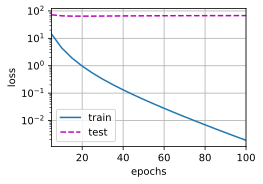

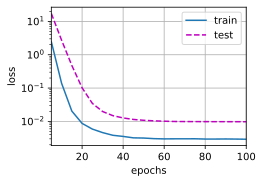

In [4]:
train_concise(0)
train_concise(3)